In [15]:
# Importa as bibliotecas usadas
import bagpipes as pipes
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit
from astropy.cosmology import Planck15
from matplotlib import pyplot as plt

### Read Data

In [16]:
snap_to_z = pd.read_pickle('snap_to_z.pkl')
etg_table = pd.read_pickle('mergers_ETGs.pkl')
#etg_table = pd.read_pickle('catalogue_ETGs.pkl')

table_massformed = np.array(etg_table['mass'])
table_SFR = np.array(etg_table['SFR'])
table_sSFR = np.array(etg_table['sSFR'])
table_met = np.array(etg_table['metallicity'])
table_dispvel = np.array(etg_table['dispvel'])
trees = np.array(etg_table['tree'])

In [17]:
num_gal = len(table_massformed)
num_gal

93214

### Estimação dos dados:

In [18]:
def dbplaw(t, A, tau, alpha, beta):
    return A*((t/tau)**alpha + (t/tau)**-beta)**-1

/tmp/ipykernel_448491/2749534632.py:2: RuntimeWarning: invalid value encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1


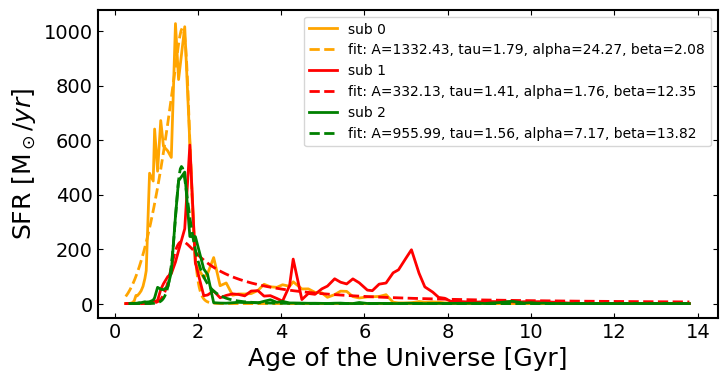

In [19]:
fig = plt.figure(figsize=(8,4))

colors = ['orange', 'red', 'green']
for i in range(0, 3):
    tree = trees[i]
    
    ages = []
    for num in tree['SnapNum']:
        redshift = snap_to_z["redshift"][num]
        universe_age = Planck15.age(redshift).value
        if universe_age == 0: universe_age = 1e-6
        ages.append(universe_age)
    
    ages = np.array(ages)
    sfr_data = tree['SubhaloSFR']
    
    # Plota os dados originais
    plt.plot(ages, sfr_data, '-', c=colors[i % 3], label='sub %d' % i)
    
    xdata = np.linspace(min(ages), max(ages), 500)

    initial_guesses = [max(sfr_data), np.median(ages), 2, 2]
    popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=20000)
    
    plt.plot(xdata, dbplaw(xdata, *popt), '--', c=colors[i % 3],
            label='fit: A=%.2f, tau=%.2f, alpha=%.2f, beta=%.2f' % tuple(popt))
    
    
plt.xlabel('Age of the Universe [Gyr]')
plt.ylabel('SFR [M$_\odot / yr$]')
plt.legend();

In [20]:
tau = np.zeros(num_gal)
alpha = np.zeros(num_gal)
beta = np.zeros(num_gal)

for i in range(num_gal):
    tree = trees[i]
    
    ages = []
    for num in tree['SnapNum']:
        redshift = snap_to_z["redshift"][num]
        universe_age = Planck15.age(redshift).value
        if universe_age == 0: universe_age = 1e-6
        ages.append(universe_age)
    
    ages = np.array(ages)
    sfr_data = tree['SubhaloSFR']
    
    try:
        initial_guesses = [max(sfr_data), np.median(ages), 5, 0.01]
        popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=100000)
        
        tau[i] = popt[1]
        alpha[i] = popt[2]
        beta[i] = popt[3]
    except: 
        print(f"Subhalo {i} não convergiu.")
        tau[i] = -1

tree_df = pd.DataFrame()
tree_df['tau'] = tau
tree_df['alpha'] = alpha
tree_df['beta'] = beta

tree_df.to_csv('merger_estimated.csv', index=False)
#tree_df.to_csv('catalogue_estimated.csv', index=False)

/tmp/ipykernel_448491/2749534632.py:2: RuntimeWarning: invalid value encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1
/tmp/ipykernel_448491/2749534632.py:2: RuntimeWarning: overflow encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1


Subhalo 305 não convergiu.


/tmp/ipykernel_448491/1364058089.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=100000)


Subhalo 1029 não convergiu.
Subhalo 1043 não convergiu.
Subhalo 1128 não convergiu.
Subhalo 1135 não convergiu.
Subhalo 1167 não convergiu.


/tmp/ipykernel_448491/2749534632.py:2: RuntimeWarning: divide by zero encountered in reciprocal
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1


...

Subhalo 71116 não convergiu.
Subhalo 71126 não convergiu.


/home/pedroand/Projects/Inference4ETGs/.venv/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T


Subhalo 71557 não convergiu.
Subhalo 71597 não convergiu.


/tmp/ipykernel_448491/2749534632.py:2: RuntimeWarning: overflow encountered in multiply
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1


Subhalo 71799 não convergiu.
Subhalo 71817 não convergiu.
Subhalo 73450 não convergiu.
Subhalo 73522 não convergiu.
Subhalo 74179 não convergiu.
Subhalo 74322 não convergiu.
Subhalo 74417 não convergiu.
Subhalo 75228 não convergiu.
Subhalo 77833 não convergiu.
Subhalo 78442 não convergiu.
Subhalo 81488 não convergiu.
Subhalo 81596 não convergiu.
Subhalo 83486 não convergiu.
Subhalo 83594 não convergiu.
Subhalo 88960 não convergiu.
Subhalo 89866 não convergiu.
Subhalo 90205 não convergiu.
Subhalo 91321 não convergiu.
Subhalo 92392 não convergiu.
Subhalo 92487 não convergiu.
Subhalo 93052 não convergiu.


In [21]:
merger_data = pd.read_csv('merger_estimated.csv')
#merger_data = pd.read_csv('catalogue_estimated.csv')
tau = np.array(merger_data['tau'])
alpha = np.array(merger_data['alpha'])
beta = np.array(merger_data['beta'])

tree_mask = (tau != -1) & (alpha < 1000) & (beta < 1000) \
            & (alpha > 0) & (beta > 0) & (tau > 1e-2)

etg_met = table_met[tree_mask]
etg_massformed = table_massformed[tree_mask]
etg_SFR = table_SFR[tree_mask]
etg_dispvel = table_dispvel[tree_mask]
alpha = alpha[tree_mask]
beta = beta[tree_mask]
tau = tau[tree_mask]

In [22]:
# Estimamos a função de densidade de probabilidade multivariada com o KDE
values = np.vstack([etg_met, np.log10(etg_massformed), etg_SFR, 
                    np.log10(etg_dispvel), np.log10(tau), np.log10(alpha), np.log10(beta)])
kernel = stats.gaussian_kde(values, bw_method='silverman')

### Plots dos resultados:

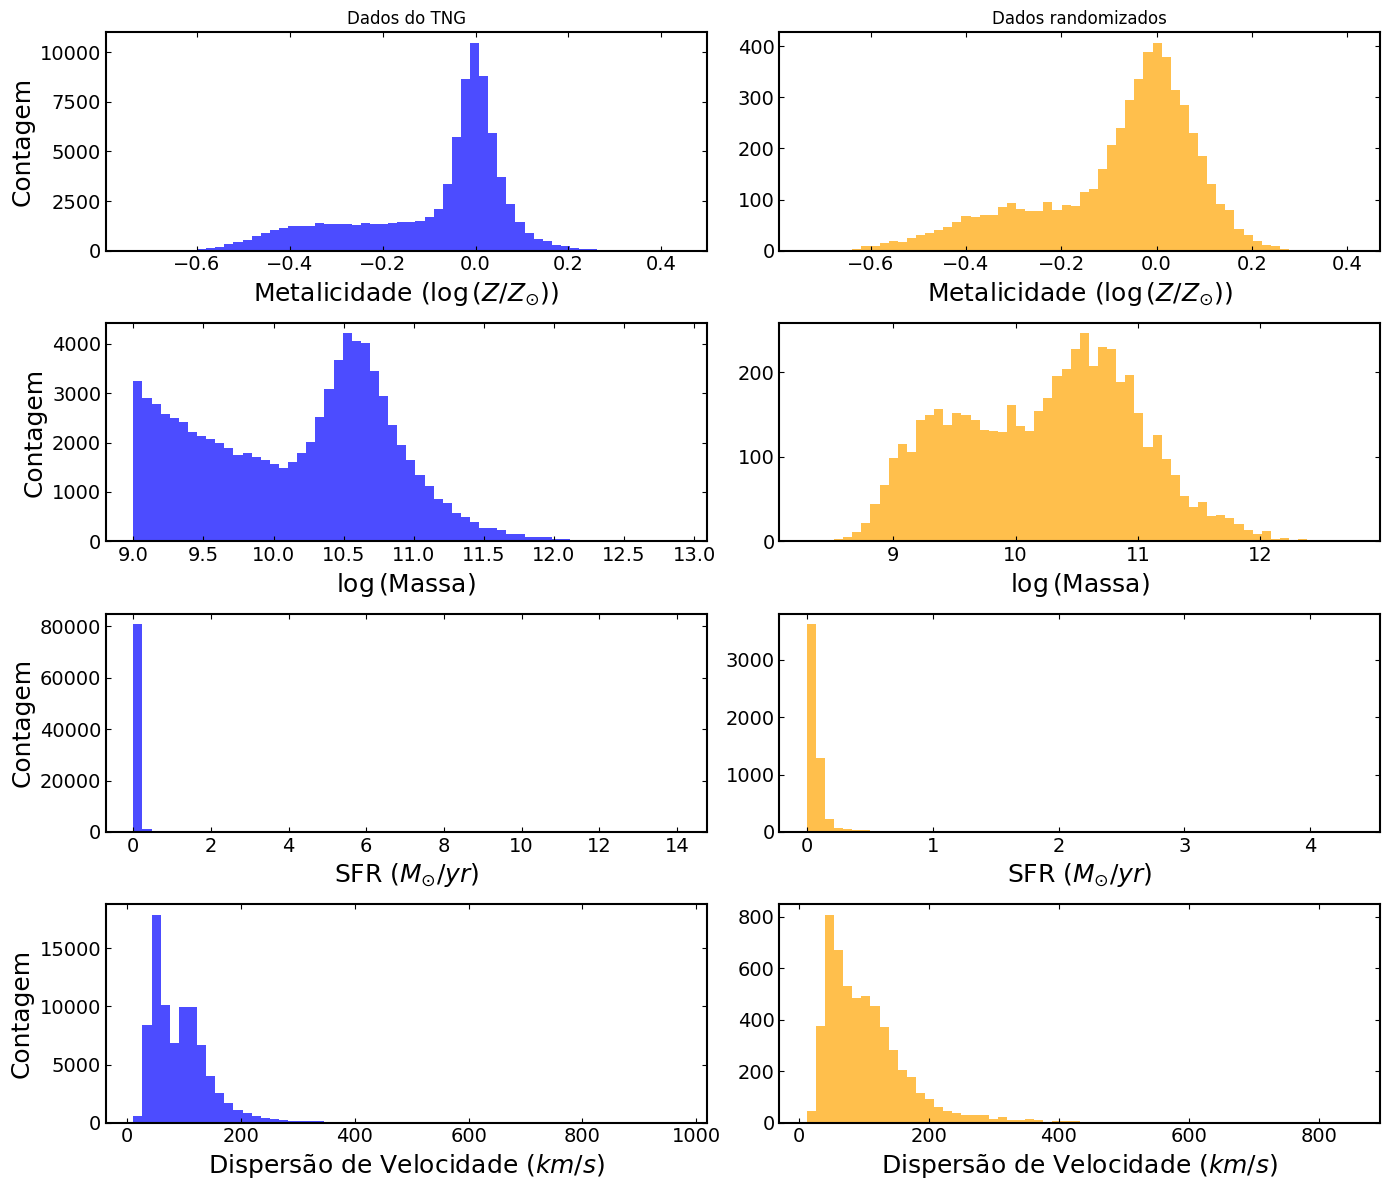

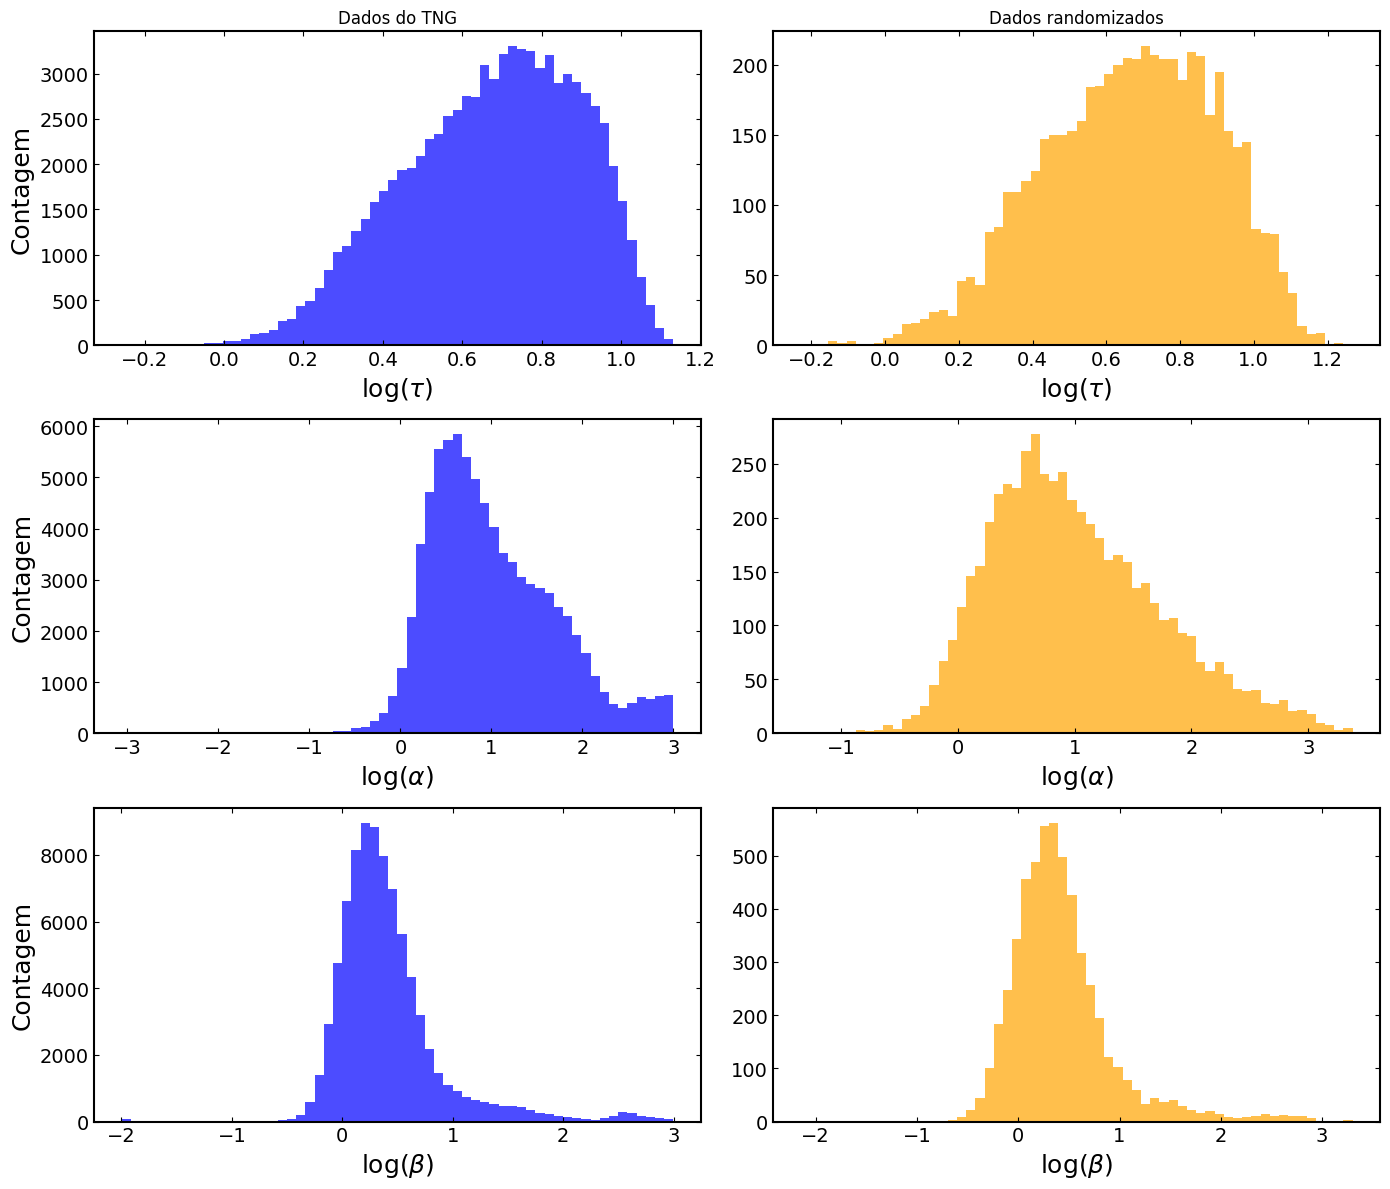

In [23]:
subplot_pos = 420

# Pega dados aleatórios baseados na distribuição original
def plot_mock(mock_data, data, name):
    global subplot_pos
    
    subplot_pos += 1
    plt.subplot(subplot_pos)
    plt.hist(data, bins=60, color='blue', alpha=0.7)
    plt.xlabel(name)
    plt.ylabel("Contagem")
    if (subplot_pos - 1) % 10 == 0: plt.title(f"Dados do TNG")
    
    subplot_pos += 1
    plt.subplot(subplot_pos)
    plt.hist(mock_data, bins=60, color='orange', alpha=0.7)
    plt.xlabel(name)
    if (subplot_pos - 2) % 10 == 0: plt.title(f"Dados randomizados")
    
# Reamostragem dos dados
mock_data = kernel.resample(10000)

mock_SFR = (mock_data[2, :])[mock_data[2, :] >= 0]
sfr_mask = (mock_data[2, :] >= 0)

mock_met = mock_data[0, :][sfr_mask]
mock_mass = (mock_data[1, :])[sfr_mask]
mock_dispvel = 10**(mock_data[3, :])[sfr_mask]

mock_tau = 10**(mock_data[4, :])[sfr_mask]
mock_alpha = 10**(mock_data[5, :])[sfr_mask]
mock_beta = 10**(mock_data[6, :])[sfr_mask]

# Plot das figuras
fig = plt.figure(figsize=(14, 12))

plot_mock(mock_met, etg_met, r"Metalicidade $(\log{(Z/Z_{\odot})})$")
plot_mock(mock_mass, np.log10(etg_massformed), r"$\log{}$(Massa)")
plot_mock(mock_SFR, etg_SFR, r"SFR $(M_{\odot} / yr)$")
plot_mock(mock_dispvel, etg_dispvel, r"Dispersão de Velocidade $(km/s)$")

plt.tight_layout()
plt.show()

# Plot da figura dos parametros da SFH
fig = plt.figure(figsize=(14, 12))
subplot_pos = 320

plot_mock(np.log10(mock_tau), np.log10(tau), r"$\log(\tau)$")
plot_mock(np.log10(mock_alpha), np.log10(alpha), r"$\log(\alpha)$")
plot_mock(np.log10(mock_beta), np.log10(beta), r"$\log(\beta)$")

plt.tight_layout()
plt.show()

In [24]:
len(mock_SFR)

5435

Massa: 9.674661274175907 
Metalicidade: -0.2503470387699527 
Dispersão de Velocidade: 65.13655364146574


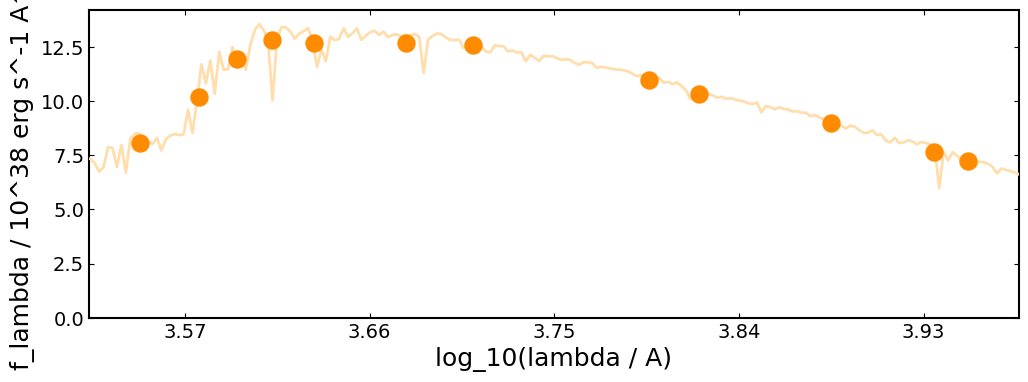

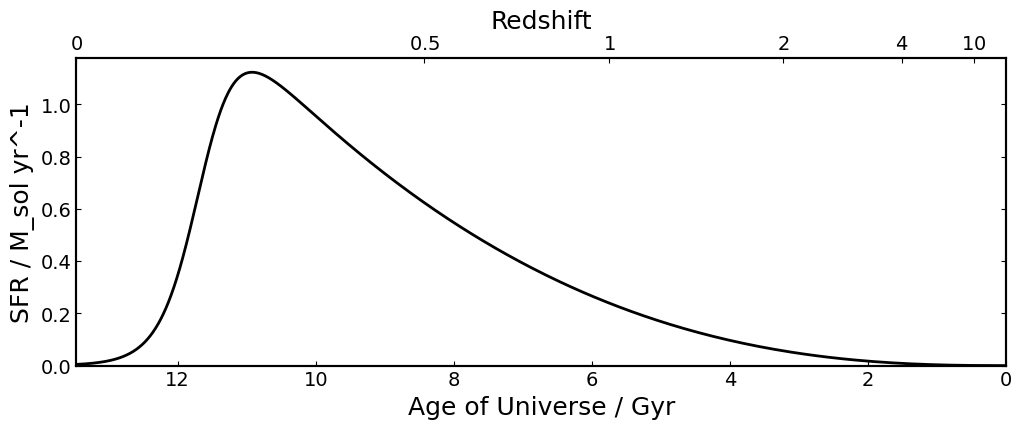

Massa: 9.260967470996171 
Metalicidade: -0.3751102928310747 
Dispersão de Velocidade: 40.67192625230672


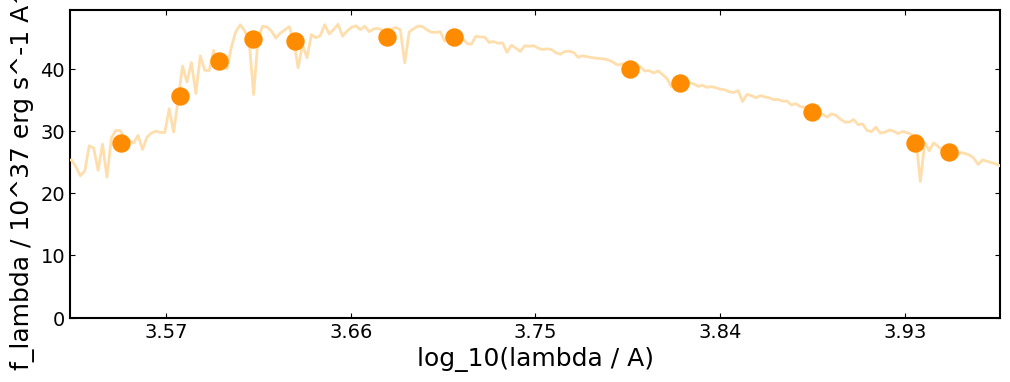

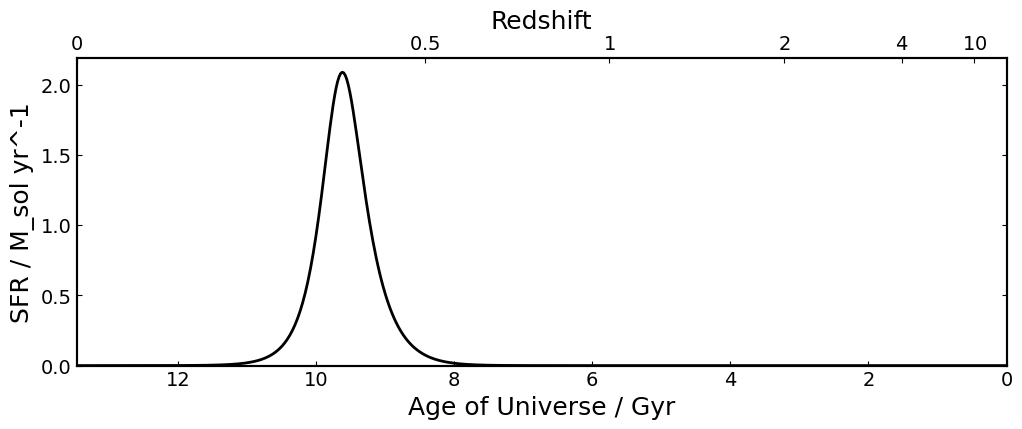

Massa: 10.909871270346802 
Metalicidade: -0.02555191340713109 
Dispersão de Velocidade: 167.2165520919913


/home/pedroand/Projects/Inference4ETGs/.venv/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


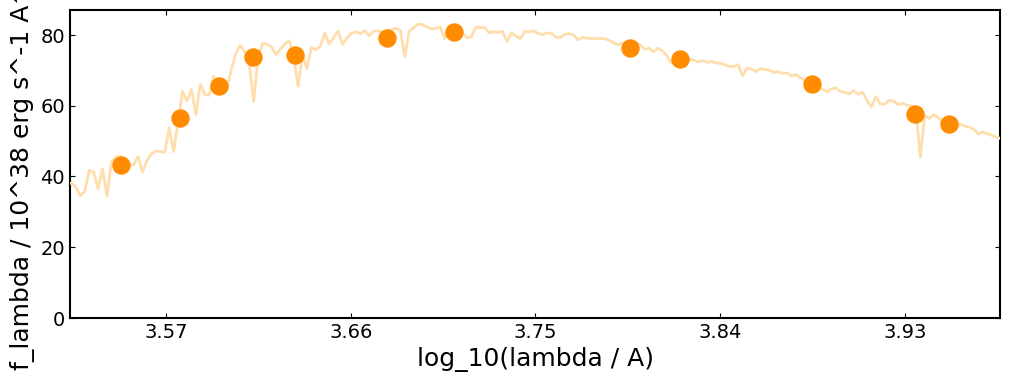

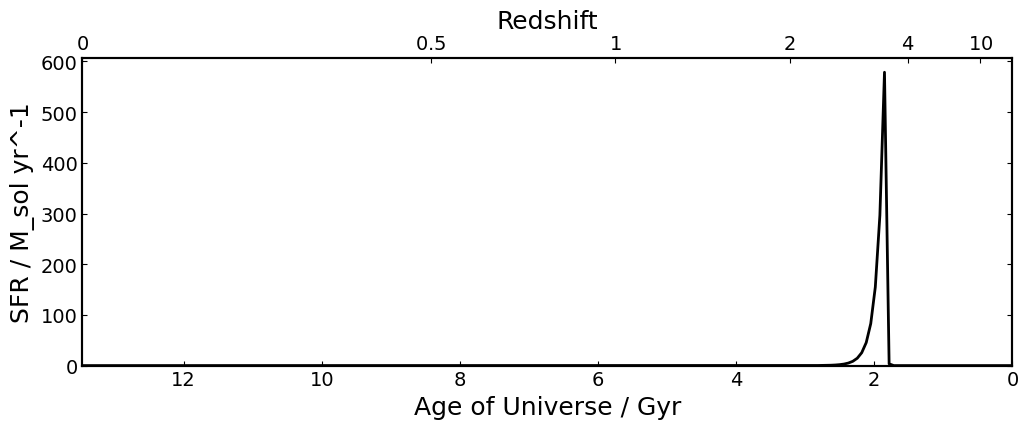

Massa: 10.334450329342989 
Metalicidade: 0.07399125298549428 
Dispersão de Velocidade: 104.74505920064296


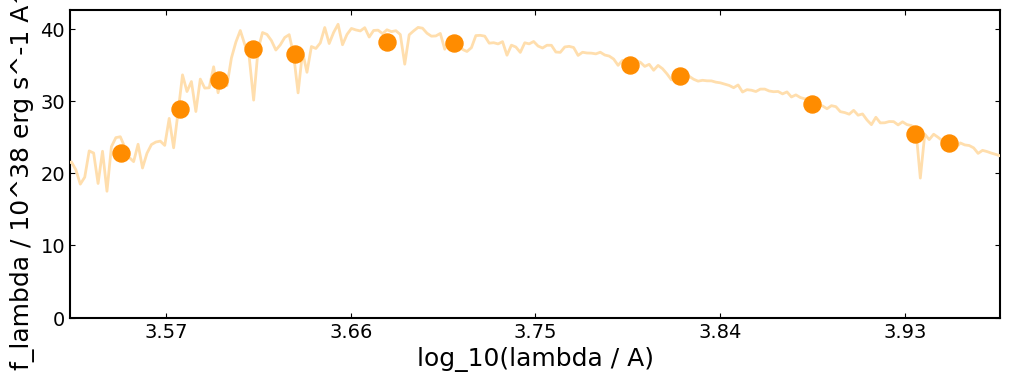

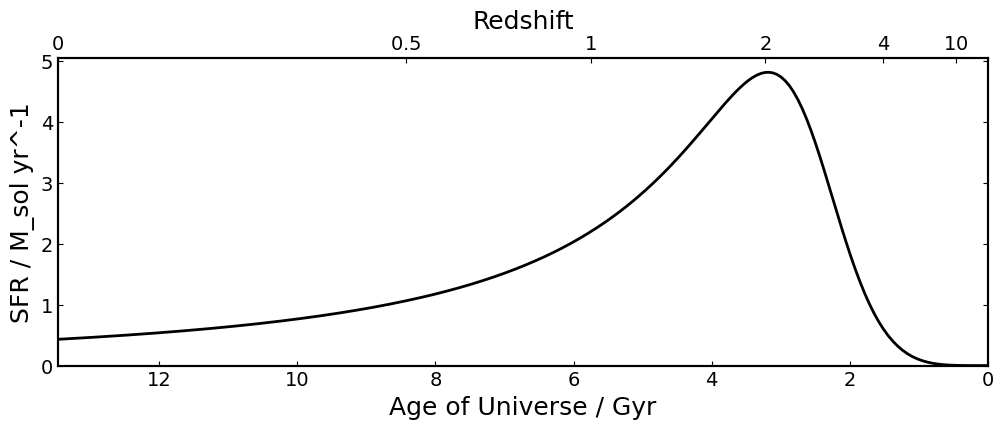

Massa: 11.315781619644735 
Metalicidade: 0.042959685845564664 
Dispersão de Velocidade: 212.75591405813887


/home/pedroand/Projects/Inference4ETGs/.venv/lib/python3.10/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


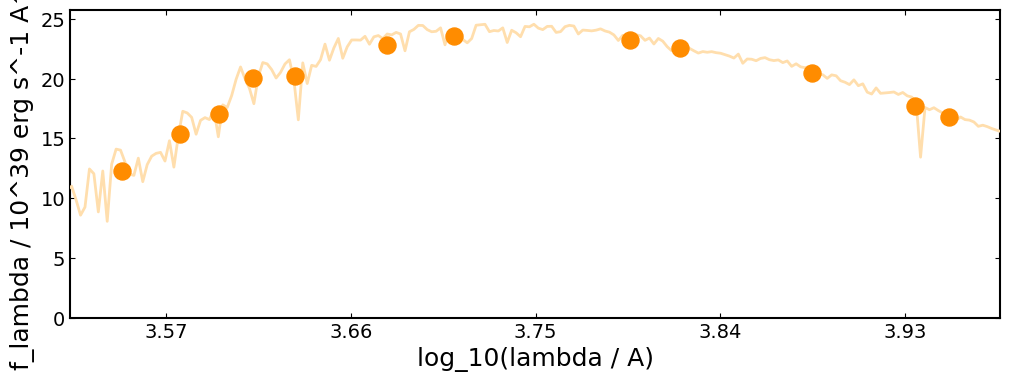

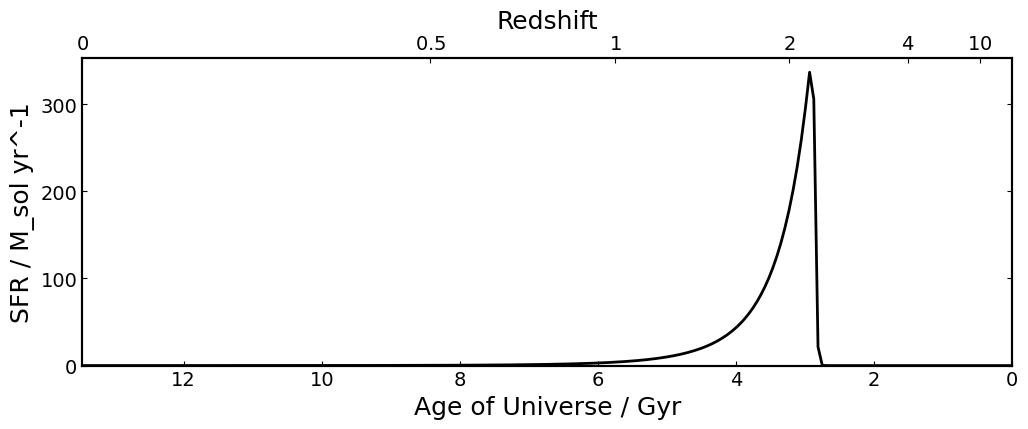

In [25]:
from numpy import random as rnd

total_samples = 5

# gera os modelos do bagpipes randomizados de acordo com as PDFs
for i in range(total_samples):
    index = rnd.randint(0, len(mock_SFR))

    metallicity = mock_met[index]
    mass = mock_mass[index]
    dispvel = mock_dispvel[index]
    tau_mock = mock_tau[index]
    alpha_mock = mock_alpha[index]
    beta_mock = mock_beta[index]
    
    print("Massa:", mass, "\nMetalicidade:", metallicity, "\nDispersão de Velocidade:", dispvel)
    
    dblplaw = {}
    dblplaw["massformed"] = mass
    dblplaw["metallicity"] = metallicity

    dblplaw["alpha"] = alpha_mock
    dblplaw["beta"] = beta_mock
    dblplaw["tau"] = tau_mock

    dust = {}
    dust["type"] = "Calzetti"
    dust["Av"] = 0.3
    dust["eta"] = 3

    model_components = {}
    model_components["dblplaw"] = dblplaw
    model_components["dust"] = dust
    model_components["redshift"] = 0 # redshift observado
    model_components["t_bc"] = 0.01 # idade máxima da nuvem molecular de uma população jovem
    model_components["veldisp"] = dispvel # dispersao de velocidade em km/s

    filt_list = np.loadtxt("splus-filters/splus_filters.txt", dtype="str")

    model = pipes.model_galaxy(model_components, filt_list=filt_list)
    #model.photometry
    model.plot()
    model.sfh.plot()